In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")
Main.include("anomalous dim\\cusp\\cusp.jl")
Main.include("anomalous dim\\non-cusp\\gammaH.jl")
Main.include("anomalous dim\\non-cusp\\gammaB.jl")
Main.include("anomalous dim\\non-cusp\\gammaS.jl")
Main.include("anomalous dim\\non-cusp\\gammav.jl")
Main.include("hard\\hard.jl")
Main.include("jet\\jet.jl")
Main.include("soft\\soft.jl")
Main.include("sigma.jl")
Main.include("error.jl")
Main.include("fixed order\\perturbation.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")

Main.include("data\\OPAL.jl")

array([3.24 , 1.3  , 1.38 , 1.197, 0.974, 0.796, 0.661, 0.553, 0.461,
       0.39 , 0.334, 0.289, 0.255, 0.227, 0.206, 0.188, 0.174, 0.161,
       0.15 , 0.141, 0.133, 0.127, 0.121, 0.116, 0.11 , 0.106, 0.102,
       0.099, 0.096, 0.093, 0.091, 0.089, 0.087, 0.085, 0.083, 0.081,
       0.081, 0.079, 0.078, 0.077, 0.076, 0.076, 0.075, 0.075, 0.075,
       0.075, 0.074, 0.074, 0.074, 0.075, 0.076, 0.076, 0.076, 0.078,
       0.078, 0.079, 0.08 , 0.082, 0.083, 0.085, 0.087, 0.089, 0.091,
       0.094, 0.096, 0.099, 0.102, 0.107, 0.11 , 0.116, 0.121, 0.125,
       0.131, 0.138, 0.146, 0.155, 0.164, 0.174, 0.186, 0.2  , 0.213,
       0.23 , 0.25 , 0.272, 0.299, 0.329, 0.365, 0.41 , 0.457, 0.521,
       0.595, 0.682, 0.783, 0.906, 1.049, 1.19 , 1.31 , 1.34 , 1.12 ,
       0.46 ])

In [4]:
χ_OPAL = np.array([
    0.9,   2.7,   4.5,   6.3,   8.1,   9.9, 
    11.7,  13.5,  15.3,  17.1,  18.9,
    20.7,  22.5,  24.3,  26.1,  27.9,  29.7, 
    31.5,  33.3,  35.1,  36.9,  38.7,
    40.5,  42.3,  44.1,  45.9,  47.7,  49.5, 
    51.3,  53.1,  54.9,  56.7,  58.5, 
    60.3,  62.1,  63.9,  65.7,  67.5,  69.3, 
    71.1,  72.9,  74.7,  76.5,  78.3,  
    80.1,  81.9,  83.7,  85.5,  87.3,  89.1, 
    90.9,  92.7,  94.5,  96.3,  98.1,  99.9, 
    101.7, 103.5, 105.3, 107.1, 108.9, 
    110.7, 112.5, 114.3, 116.1, 117.9, 119.7, 
    121.5, 123.3, 125.1, 126.9, 128.7, 
    130.5, 132.3, 134.1, 135.9, 137.7, 139.5, 
    141.3, 143.1, 144.9, 146.7, 148.5,
    150.3, 152.1, 153.9, 155.7, 157.5, 159.3,
    161.1, 162.9, 164.7, 166.5, 168.3,
    170.1, 171.9, 173.7, 175.5, 177.3, 179.1
])

EEC_OPAL = np.array([
    3.24,  1.30,  1.38,  1.197, 0.974, 0.796, 
    0.661, 0.553, 0.461, 0.390, 0.334, 
    0.289, 0.255, 0.227, 0.206, 0.188, 0.174, 
    0.161, 0.150, 0.141, 0.133, 0.127, 
    0.121, 0.116, 0.110, 0.106, 0.102, 0.099, 
    0.096, 0.093, 0.091, 0.089, 0.087, 
    0.085, 0.083, 0.081, 0.081, 0.079, 0.078, 
    0.077, 0.076, 0.076, 0.075, 0.075, 
    0.075, 0.075, 0.074, 0.074, 0.074, 0.075, 
    0.076, 0.076, 0.076, 0.078, 0.078, 0.079, 
    0.080, 0.082, 0.083, 0.085, 0.087, 
    0.089, 0.091, 0.094, 0.096, 0.099, 0.102, 
    0.107, 0.110, 0.116, 0.121, 0.125, 
    0.131, 0.138, 0.146, 0.155, 0.164, 0.174, 
    0.186, 0.200, 0.213, 0.230, 0.250, 
    0.272, 0.299, 0.329, 0.365, 0.410, 0.457, 
    0.521, 0.595, 0.682, 0.783, 0.906, 
    1.049, 1.19,  1.31,  1.34,  1.12,  0.46
])

In [26]:
xlist = np.pi/180*np.linspace(0,180,500)
perturbation_1 = []
perturbation_2 = []

for x in xlist:
    perturbation_1.append(Main.perturbation_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=1))    
    perturbation_2.append(Main.perturbation_sigma_χ(χ=x, Q=91.2, μ_ini=91.1876, αs_ini=0.118, nf=5, order=2))
print(perturbation_2)

[nan, 4337514492064929.0, 8471585127733.684, 220360043486.56693, 16545104757.406513, 2220549732.7008977, 430334522.56906366, 107462707.2100691, 32307157.654979892, 11191552.900939295, 4335438.797683145, 1838462.8575632595, 840058.7588333035, 408694.23537931, 209739.49532240033, 112707.0979631399, 63041.89079475275, 36525.98798269923, 21833.332623186736, 13418.938130212095, 8455.844151218866, 5449.780077624206, 3584.880863677292, 2402.4624183558212, 1637.714433772496, 1134.0124319753259, 796.6462710268742, 567.1687785414753, 408.8288187988354, 298.11347255220477, 219.73561202745626, 163.60640209503546, 122.97413096017179, 93.26107712328272, 71.32535858747264, 54.98569848036453, 42.7113033250972, 33.41690458988742, 26.32567304513851, 20.876490148657496, 16.660551443706456, 13.377584133299692, 10.80531980216868, 8.778015068259505, 7.1712075105776325, 5.890807447717722, 4.865231020516116, 4.039684085612477, 3.3719791137106014, 2.829453034678494, 2.3866813541819494, 2.023772221195626, 1.725

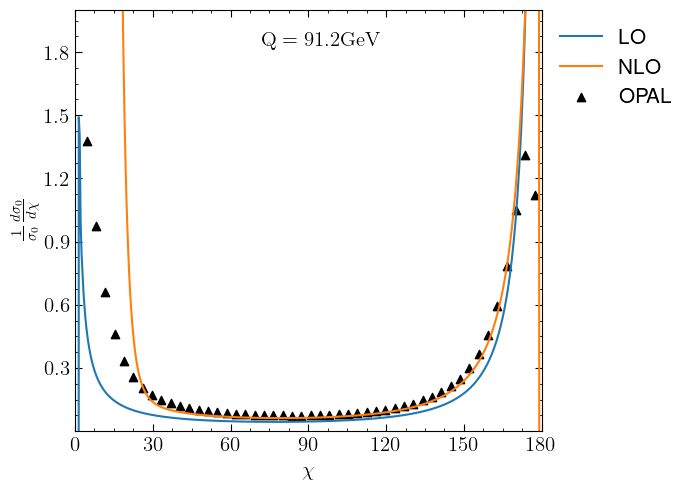

In [30]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 5)) 

sizeOfFont = 15
sizeOfTick = 15

ax1.plot(xlist*180/np.pi, perturbation_1, label="LO")
ax1.plot(xlist*180/np.pi, perturbation_2, label="NLO")
ax1.scatter(χ_OPAL[::2], EEC_OPAL[::2], label="OPAL",marker="^",color="black")

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_0} \frac{d \sigma_0}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
verticalalignment='top', bbox=props)

plt.ylim(0,2)
plt.xlim(0,180)

plt.xticks([0,30,60,90,120,150,180])
plt.yticks([0.3,0.6,0.9,1.2,1.5,1.8])


plt.tight_layout()  
plt.show()